# Human Eye vs. Jalali-Instrument Optics

One piece of vector calculus -- the differential area element on a sphere,
$d\vec{A} = r^2\sin\theta\,d\theta\,d\phi\,\hat{r}$, built the same way
Feynman (*Lectures*, Vol. II) and Griffiths (*Introduction to
Electrodynamics*, Ch. 1 spherical coordinates; Ch. 11 radiated power per
solid angle $dP/d\Omega$) both build it -- run through the same integral,
$\Phi = \int (dP/d\Omega)\,d\Omega$, twice: once for a human pupil, once
for a Jalali-lab time-stretch instrument's collection lens (SEALS's own
default NA=0.70). The light source is held fixed: Mie scattering off a
dielectric sphere, using the same $\pi_n,\tau_n$ angular-function
recurrence already verified in `seals_stable.ipynb` Sec. 4-5.
Engine: `dgs/human_vs_instrument_optics.py`.

**Honesty note.** "Nuclear Griffiths" doesn't map to anything concrete
here or in Griffiths' *Electrodynamics* -- the real Griffiths material
used below is Ch. 11's $dP/d\Omega$ formalism.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import human_vs_instrument_optics as hio

sp.init_printing()
print('Setup complete.')


Setup complete.


## 1. The Differential Area Element (Feynman + Griffiths)

$$d\vec{A} = \left(\frac{\partial \vec{r}}{\partial\theta}\right)
             \times \left(\frac{\partial \vec{r}}{\partial\phi}\right)
             d\theta\,d\phi$$

is the general curvilinear-coordinates construction both texts use. For a
sphere of radius $r$, this gives $|d\vec{A}| = r^2\sin\theta\,d\theta\,d\phi$,
so the solid-angle element is $d\Omega = dA/r^2 = \sin\theta\,d\theta\,d\phi$
-- the object every "how much light does a detector collect" calculation
below is built from.


In [2]:
dA = hio.derive_spherical_area_element_symbolic()
display(Math(r'|d\vec{A}|/(d\theta\,d\phi) = ' + sp.latex(dA)))

omega_full = hio.verify_full_sphere_solid_angle()
print(f'Full-sphere solid angle (numeric check): {omega_full:.6f} sr  (expect 4*pi = {4*np.pi:.6f})')


<IPython.core.display.Math object>

Full-sphere solid angle (numeric check): 12.566370 sr  (expect 4*pi = 12.566371)


## 2. Mie Scattering's Angular Trig Functions

The light source: a dielectric sphere (SEALS's own default, 9.94 $\mu$m,
$n=1.39$). The scattered-field angular dependence comes from the
$\pi_n(\cos\theta), \tau_n(\cos\theta)$ recurrence
(`dgs.human_vs_instrument_optics._angular_functions`, ported from
`seals_stable.ipynb` Sec. 4 -- same fixed `range(2,nmax)` recurrence, same
complex Mie coefficients $a_n, b_n$). $S_1(\theta), S_2(\theta)$ combine
these with $a_n, b_n$; $dP/d\Omega \propto \tfrac{1}{2}(|S_1|^2+|S_2|^2)$
is the differential scattering pattern -- Griffiths' $dP/d\Omega$
formalism (Ch. 11), applied to a scattering rather than a radiating
source.


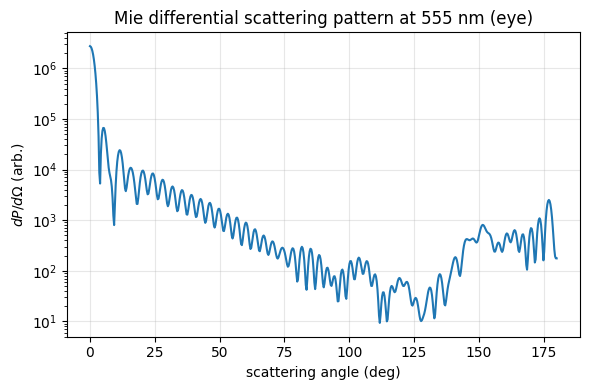

Sharp, narrow forward peak: this particle has a LARGE Mie size parameter at 555nm.


In [3]:
theta_plot = np.linspace(1e-4, np.pi, 600)
S1, S2 = hio.mie_s1_s2(1.39, 1.00, 9940e-6, 0.555e-3, theta_plot)  # eye's 555nm, mm units
dPdOmega = 0.5*(np.abs(S1)**2 + np.abs(S2)**2)

plt.figure(figsize=(6,4))
plt.semilogy(np.degrees(theta_plot), dPdOmega)
plt.xlabel('scattering angle (deg)'); plt.ylabel(r'$dP/d\Omega$ (arb.)')
plt.title('Mie differential scattering pattern at 555 nm (eye)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Sharp, narrow forward peak: this particle has a LARGE Mie size parameter at 555nm.')


## 3. Optical-System Metrics: Eye vs. Instrument

Both a human pupil and a lens are just an aperture + focal length. The
same four numbers -- NA, f-number, Rayleigh diffraction limit, acceptance
solid angle $\Omega=2\pi(1-\cos\theta_{1/2})$ from Section 1 -- describe
either one. `HUMAN_EYE` uses a typical 4mm daylight pupil and the eye's
~17mm effective focal length at 555nm (photopic peak). `JALALI_INSTRUMENT`
uses SEALS's own default collection lens: 5.8mm diameter, NA=0.70 exactly
(via `_focal_length_from_NA`, the non-paraxial inversion -- NA=0.70 is too
large for the small-angle approximation), at the 1590nm telecom C-band
Jalali-lab time-stretch instruments operate in.


In [4]:
print(hio.HUMAN_EYE)
print(hio.JALALI_INSTRUMENT)
print()
for name, params in [('Human eye', hio.HUMAN_EYE), ('Jalali instrument', hio.JALALI_INSTRUMENT)]:
    m = hio.optical_system_metrics(**params)
    print(f"{name:18s}  NA={m['NA']:.3f}  f/#={m['f_number']:.2f}  "
          f"Rayleigh={m['theta_rayleigh_arcsec']:.2f} arcsec  "
          f"Omega_accept={m['acceptance_solid_angle_sr']:.4e} sr")


{'aperture_diameter_mm': 4.0, 'focal_length_mm': 17.0, 'wavelength_nm': 555.0}
{'aperture_diameter_mm': 5.8, 'focal_length_mm': np.float64(2.9585917775391812), 'wavelength_nm': 1590.0}

Human eye           NA=0.117  f/#=4.25  Rayleigh=34.92 arcsec  Omega_accept=4.3036e-02 sr
Jalali instrument   NA=0.700  f/#=0.51  Rayleigh=68.98 arcsec  Omega_accept=1.7961e+00 sr


## 4. Collected Scattering Flux

$$\Phi = \int_0^{\theta_{max}} \frac{dP}{d\Omega}\, 2\pi\sin\theta\,d\theta$$

integrated over each system's own acceptance half-angle from Section 3,
at each system's own wavelength.


In [5]:
c = hio.compare_eye_vs_instrument_collection()
print(f"eye:        flux={c['eye']['collected_flux']:.4e}  "
      f"Omega={c['eye']['acceptance_solid_angle_sr']:.4e} sr")
print(f"instrument: flux={c['instrument']['collected_flux']:.4e}  "
      f"Omega={c['instrument']['acceptance_solid_angle_sr']:.4e} sr")
print(f"\nratio (instrument/eye) = {c['flux_ratio_instrument_over_eye']:.3f}")


eye:        flux=1.0059e+04  Omega=4.3036e-02 sr
instrument: flux=2.0972e+03  Omega=1.7961e+00 sr

ratio (instrument/eye) = 0.208


**Counter-intuitive result, checked for convergence (not a numerical
artifact -- stable from 500 to 32000 integration points):** despite a
~42x larger acceptance solid angle, the instrument collects *less* total
flux than the eye from this particle. Why: Mie size parameter
$x=\pi d/\lambda$ is ~56 at the eye's 555nm vs. ~20 at the instrument's
1590nm. Larger $x$ means a much narrower, much brighter forward
diffraction lobe (Fraunhofer-type scaling) -- and that entire lobe fits
inside the eye's much smaller acceptance cone. Bigger aperture does not
automatically mean more collected light; the particle's own
wavelength-dependent diffraction physics can dominate.


## 5. Dynamic Range: Weber-Fechner vs. Linear ADC Bits

The eye doesn't use a fixed linear gain -- it compresses intensity
logarithmically (Weber-Fechner law), the same log-compression math as
$\mu$-law/A-law companding in digital audio. A linear-response instrument
(camera ADC) instead needs enough *bits* to span the same intensity
ratio without saturating or quantizing to zero:
$$\text{bits} = \log_2(\text{max/min intensity ratio})$$


In [6]:
eye_bits = hio.dynamic_range_bits(hio.EYE_DYNAMIC_RANGE_RATIO)
print(f"Eye's full adapted range (~{hio.EYE_DYNAMIC_RANGE_RATIO:.0e}:1) would need "
      f"{eye_bits:.1f} bits of LINEAR ADC resolution to match.")
print()
for cam, bits in hio.CAMERA_ADC_BITS.items():
    print(f"{cam:22s}: {bits:2d} bits -> {2**bits:6.0f}:1 linear dynamic range")


Eye's full adapted range (~1e+09:1) would need 29.9 bits of LINEAR ADC resolution to match.

8-bit camera          :  8 bits ->    256:1 linear dynamic range
12-bit camera         : 12 bits ->   4096:1 linear dynamic range
14-bit scientific CCD : 14 bits ->  16384:1 linear dynamic range


## 6. Temporal Resolution: Flicker Fusion vs. Time-Stretch

The eye's ~60Hz flicker-fusion rate sets its effective frame time. A
Jalali-lab time-stretch instrument's temporal resolution is set by its
oscilloscope bandwidth (`dispersive_fourier_teaching.py`'s own
`LAB_PARAMS['osc_BW_GHz']=40.0` default) -- the dispersion kernel
$H(f)=\exp(i\pi D f^2)$ this whole repo is organized around is exactly
what makes that bandwidth usable as a *time* resolution (frequency-to-time
mapping, Problem 2 of `dispersion_calculus_problems.ipynb`).


In [7]:
t = hio.temporal_resolution_comparison()
print(f"eye frame time         = {t['eye_frame_time_s']*1e3:.2f} ms")
print(f"instrument resolution  = {t['instrument_resolution_s']*1e12:.3f} ps")
print(f"instrument is {t['speedup_factor']:.2e}x faster")


eye frame time         = 16.67 ms
instrument resolution  = 12.500 ps
instrument is 1.33e+09x faster


## Summary

| Metric | Human eye | Jalali instrument | Winner |
|---|---|---|---|
| NA | ~0.12 | 0.70 (exact, SEALS default) | instrument (wider acceptance) |
| Rayleigh resolution | ~35 arcsec | ~69 arcsec | eye (shorter wavelength) |
| Collected flux (this particle) | higher | lower | eye (narrower, brighter forward lobe at 555nm) |
| Dynamic range | ~30 bits equiv. (log-compressed) | 8-14 bits (linear) | eye |
| Temporal resolution | ~17 ms | ~12.5 ps | instrument, by ~10^9x |

No single system "wins" outright -- the eye's advantage is adaptive
dynamic range and (for this particular particle) a favorably narrow
diffraction lobe; the instrument's advantage is raw temporal resolution
and engineerable NA/wavelength. Full test coverage:
`tests/test_human_vs_instrument_optics.py`.
